## Selection of appropriate k-fold Cross-validation 

In [ ]:
# Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder

# Load dataset
dataset = pd.read_excel('BBDM Project.xlsx')

# Separate features and target variable
X = dataset.drop(columns='RMC', axis=1)
y = dataset['RMC']

# Encode the target variable into numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Initialize the scaler
scaler = RobustScaler()

# Fit on the training data
scaler.fit(X_train)  # Fit on the training data

# Transform both the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a range of k values
k_values = [2, 5, 10, 15, 20]

# Create a dictionary to store mean cross-validation scores for each model
mean_scores = {}

# Models
models = {
    'LR': LogisticRegression(),
    'DT': DecisionTreeClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'RF': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'Bagging': BaggingClassifier()
}

# Choose an appropriate metric (e.g., 'accuracy', 'precision', 'recall', 'f1')
metric = 'accuracy'

# Perform cross-validation for each model and each k value
for model_name, model in models.items():
    model_mean_scores = []
    for k in k_values:
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring=metric)
        model_mean_scores.append(scores.mean())
    
    mean_scores[model_name] = model_mean_scores

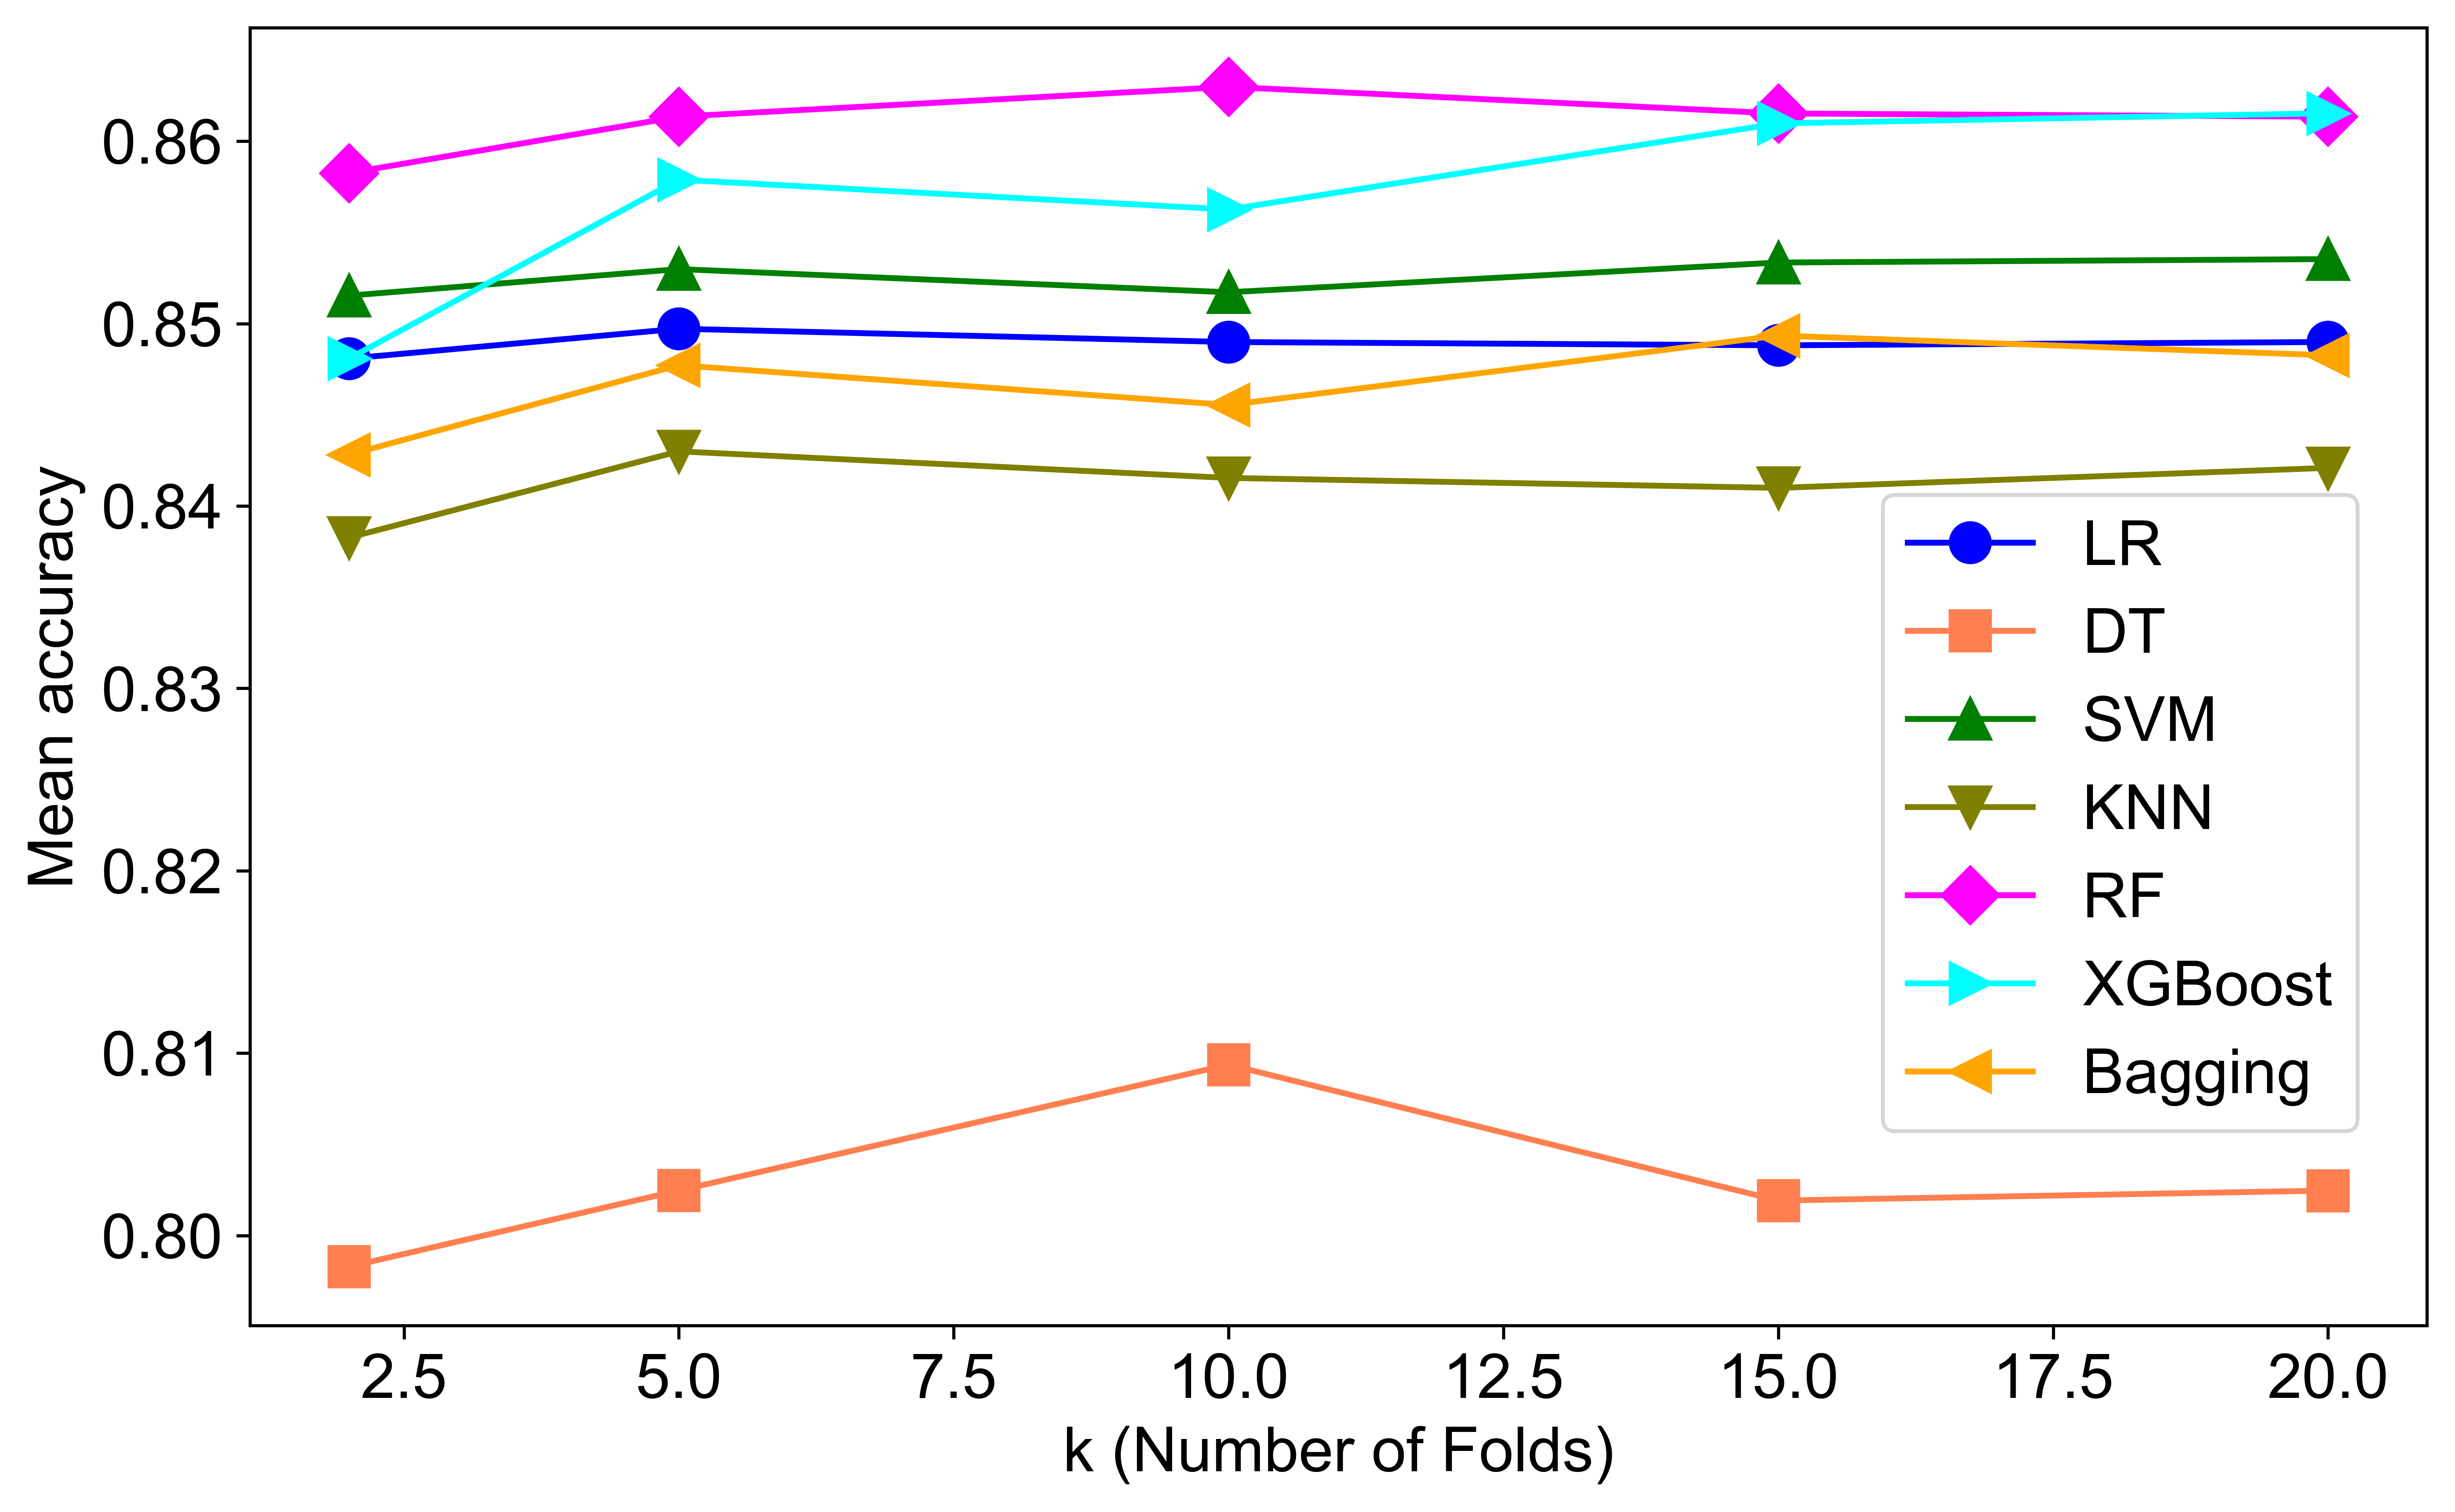

In [2]:
from matplotlib import pyplot
# Define colors for each model
model_colors = {
    'LR': 'blue',
    'SVM': 'green',
    'DT': 'coral',
    'RF': 'magenta',
    'KNN': 'olive',
    'XGBoost': 'cyan',
    'Bagging': 'orange'
}
# Define markers for each model
model_markers = {
    'LR': 'o',
    'SVM': '^',
    'DT': 's',
    'RF': 'D',
    'KNN': 'v',
    'XGBoost': '>',
    'Bagging': '<'
}
# Set font
plt.rcParams['font.family'] = 'Arial'

# Plot the results for each model with different colors
plt.figure(figsize=(10, 6), dpi=800)
for model_name, scores in mean_scores.items():
    plt.plot(k_values, scores, marker=model_markers.get(model_name, 'o'), markersize=10, label=model_name, color=model_colors.get(model_name, 'gray'))

#plt.title(f'Cross-Validation Performance ({metric}) for Different k Values', fontsize=18)
plt.xlabel('k (Number of Folds)', fontsize=16)
plt.ylabel(f'Mean {metric}', fontsize=16)

# Increase font size for x and y-axis tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Set the legend position using coordinates (adjust as needed)
plt.legend(loc=(0.75, 0.15), fontsize=16)

plt.show()

## 
The output results indicated that the tenfold cross-validation technique has better performance in all classification models.